In [1]:
import pandas as pd

# Load the CSV file for Ethiopia
df = pd.read_csv("D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\ethiopia.csv")

# Add a Country column
df["Country"] = "Ethiopia"

# Convert YEAR and DOY to a proper datetime column
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month as a separate column
df["Month"] = df["Date"].dt.month

df.tail()

<>:4: SyntaxWarning: invalid escape sequence '\A'
<>:4: SyntaxWarning: invalid escape sequence '\A'
C:\Users\a00928253\AppData\Local\Temp\ipykernel_20732\1599543420.py:4: SyntaxWarning: invalid escape sequence '\A'
  df = pd.read_csv("D:\Aman\KAIM-9\Week-0\Week0-climate-challange\climate-challenge-week0\data\ethiopia.csv")


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3
4107,2026,90,18.25,26.36,12.14,14.22,0.40,63.95,2.18,3.64,76.47,10.14,Ethiopia,2026-03-31,3


In [2]:
import numpy as np

# Replace all -999 with np.nan
df = df.replace(-999, np.nan)

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Drop duplicates if any
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

Number of duplicate rows: 0


In [19]:
# Run df.describe() on all numeric columns
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


## Interpretation of Summary Statistics
The df.describe() output shows the distribution of numeric columns in the dataset. Key metrics include:
- **count**: Number of non-null values for each column
- **mean**: Average value - useful for understanding central tendency
- **std**: Standard deviation - indicates variability in the data
- **min/max**: Range of values - helps identify outliers
- **25%, 50%, 75%**: Quartiles - useful for understanding distribution shape

In [3]:
# Check missing values
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Filter columns with >5% missing
high_missing = missing_summary[missing_summary['Missing %'] > 5]
print("Columns with >5% missing values:")
print(high_missing)

# Show all missing values
print("\nAll columns with missing values:")
print(missing_summary[missing_summary['Missing Count'] > 0])

Columns with >5% missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

All columns with missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


## Missing Value Analysis
Columns with >5% missing values may indicate:
- Data collection issues or sensor malfunctions
- Need for imputation strategies (mean, median, interpolation)
- Potential bias if missingness is not random

Review these columns carefully before proceeding with analysis.

In [9]:
pip install scipy

  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [10]:
from scipy.stats import zscore

cols = [
    "T2M",
    "T2M_MAX",
    "T2M_MIN",
    "PRECTOTCORR",
    "RH2M",
    "WS2M",
    "WS2M_MAX"
]

z_scores = np.abs(df[cols].apply(zscore))

outliers = (z_scores > 3).sum()
print(outliers)

T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


In [12]:
pip install matplotlib seaborn

  Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-win_amd64.whl (8.2 MB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl (7.1 MB)
U

<Axes: xlabel='Date'>

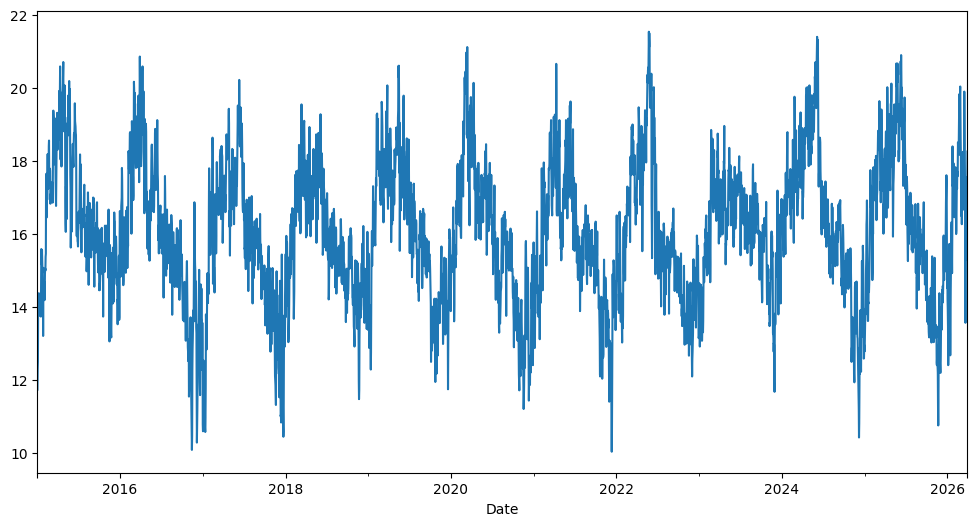

In [13]:
monthly_temp = df.groupby("Date")["T2M"].mean()

monthly_temp.plot(figsize=(12,6))

<Axes: xlabel='Month'>

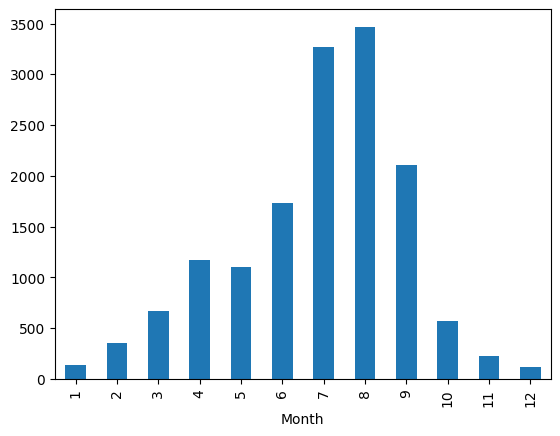

In [14]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")

<Axes: >

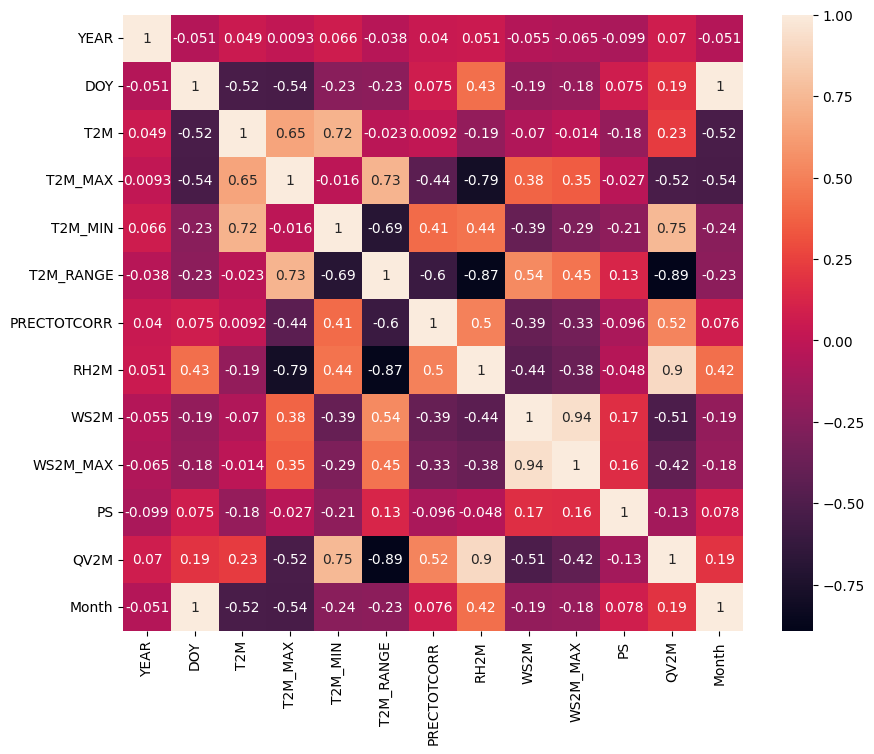

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True)

<Axes: xlabel='T2M', ylabel='RH2M'>

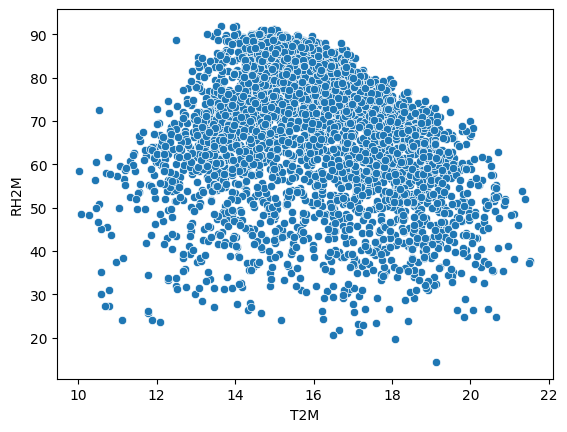

In [16]:
sns.scatterplot(data=df, x="T2M", y="RH2M")

<Axes: xlabel='T2M_RANGE', ylabel='WS2M'>

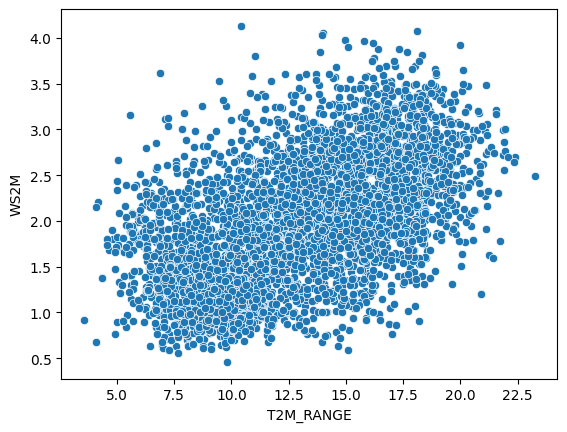

In [17]:
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")

<Axes: xlabel='PRECTOTCORR', ylabel='Count'>

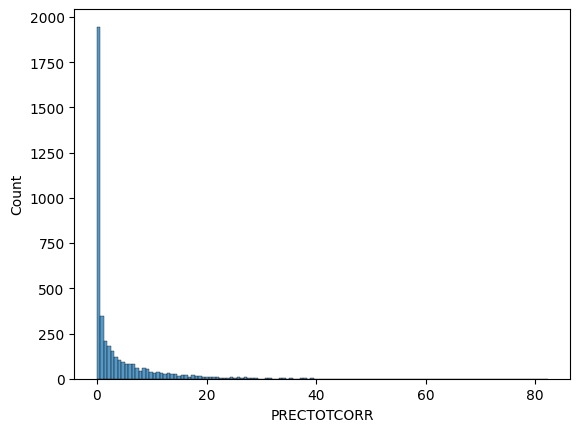

In [18]:
sns.histplot(df["PRECTOTCORR"])

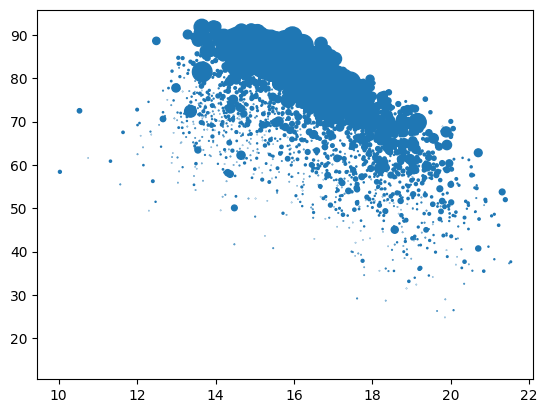

In [19]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*5
)